# Zadání 1 - Výpočet základních statistických charakteristik náhodných veličin


## Načtení dat a vizualizace vstupního a výstupního signálu v čase


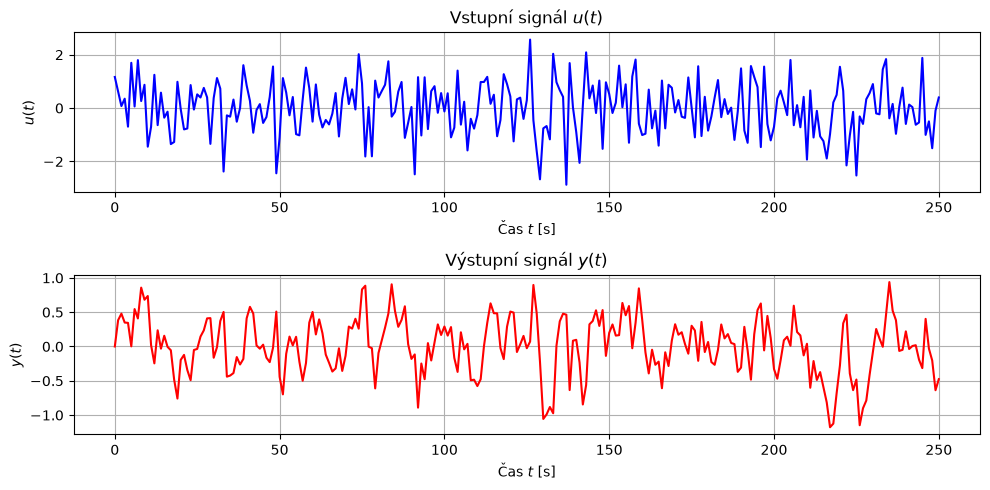

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

u = pd.read_csv('u.csv', header=None).values.flatten()
y = pd.read_csv('y.csv', header=None).values.flatten()

Ts = 1.0
t = np.arange(len(u)) * Ts

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t, u, 'b')
plt.title(r'Vstupní signál $u(t)$')
plt.xlabel(r'Čas $t\ [\mathrm{s}]$')
plt.ylabel(r'$u(t)$')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y, 'r')
plt.title(r'Výstupní signál $y(t)$')
plt.xlabel(r'Čas $t\ [\mathrm{s}]$')
plt.ylabel(r'$y(t)$')
plt.grid(True)
plt.tight_layout()
plt.savefig("prubehy.png", dpi=300)
plt.show()


## Výpočet základních statistických charakteristik a kovarianční matice


In [2]:
N = len(u)

m_u = np.sum(u) / N
m_y = np.sum(y) / N

s2_u = np.sum((u - m_u)**2) / N
s2_y = np.sum((y - m_y)**2) / N
s_u = np.sqrt(s2_u)
s_y = np.sqrt(s2_y)

C_uy = np.sum((u - m_u) * (y - m_y)) / N
r_uy = C_uy / (s_u * s_y)

C_X = np.array([[s2_u, C_uy], [C_uy, s2_y]])
C_cov = np.cov(u, y, bias=True)

stats_df = pd.DataFrame({
    'Statistická charakteristika': [
        'Střední hodnota mᵤ',
        'Střední hodnota mᵧ',
        'Rozptyl s²ᵤ',
        'Rozptyl s²ᵧ',
        'Směrodatná odchylka sᵤ',
        'Směrodatná odchylka sᵧ',
        'Kovariance Cᵤᵧ',
        'Koeficient korelace rᵤᵧ'
    ],
    'Hodnota': [
        f"{m_u:.5f}",
        f"{m_y:.5f}",
        f"{s2_u:.5f}",
        f"{s2_y:.5f}",
        f"{s_u:.5f}",
        f"{s_y:.5f}",
        f"{C_uy:.5f}",
        f"{r_uy:.5f}"
    ]
})

cov_formula_df = pd.DataFrame(
    C_X,
    index=['u', 'y'],
    columns=['u', 'y']
).map(lambda val: f"{val:.8f}")

cov_func_df = pd.DataFrame(
    C_cov,
    index=['u', 'y'],
    columns=['u', 'y']
).map(lambda val: f"{val:.8f}")

print("Základní statistické charakteristiky:")
display(stats_df)

print("\nKovarianční matice C_X (dle vzorce):")
display(cov_formula_df)

print("\nKovarianční matice (funkce cov):")
display(cov_func_df)

print(f"Maximální absolutní rozdíl matic: {np.max(np.abs(C_X - C_cov)):.2e}")


Základní statistické charakteristiky:


,Statistická charakteristika,Hodnota
0,Střední hodnota mᵤ,0.00591
1,Střední hodnota mᵧ,0.00789
2,Rozptyl s²ᵤ,1.00767
3,Rozptyl s²ᵧ,0.17159
4,Směrodatná odchylka sᵤ,1.00383
5,Směrodatná odchylka sᵧ,0.41424
6,Kovariance Cᵤᵧ,-0.04175
7,Koeficient korelace rᵤᵧ,-0.10041



Kovarianční matice C_X (dle vzorce):


,u,y
u,1.00767043,-0.04175372
y,-0.04175372,0.17159415



Kovarianční matice (funkce cov):


,u,y
u,1.00767043,-0.04175372
y,-0.04175372,0.17159415


Maximální absolutní rozdíl matic: 2.08e-17


## Zobrazení histogramů četností a diskrétních distribučních funkcí


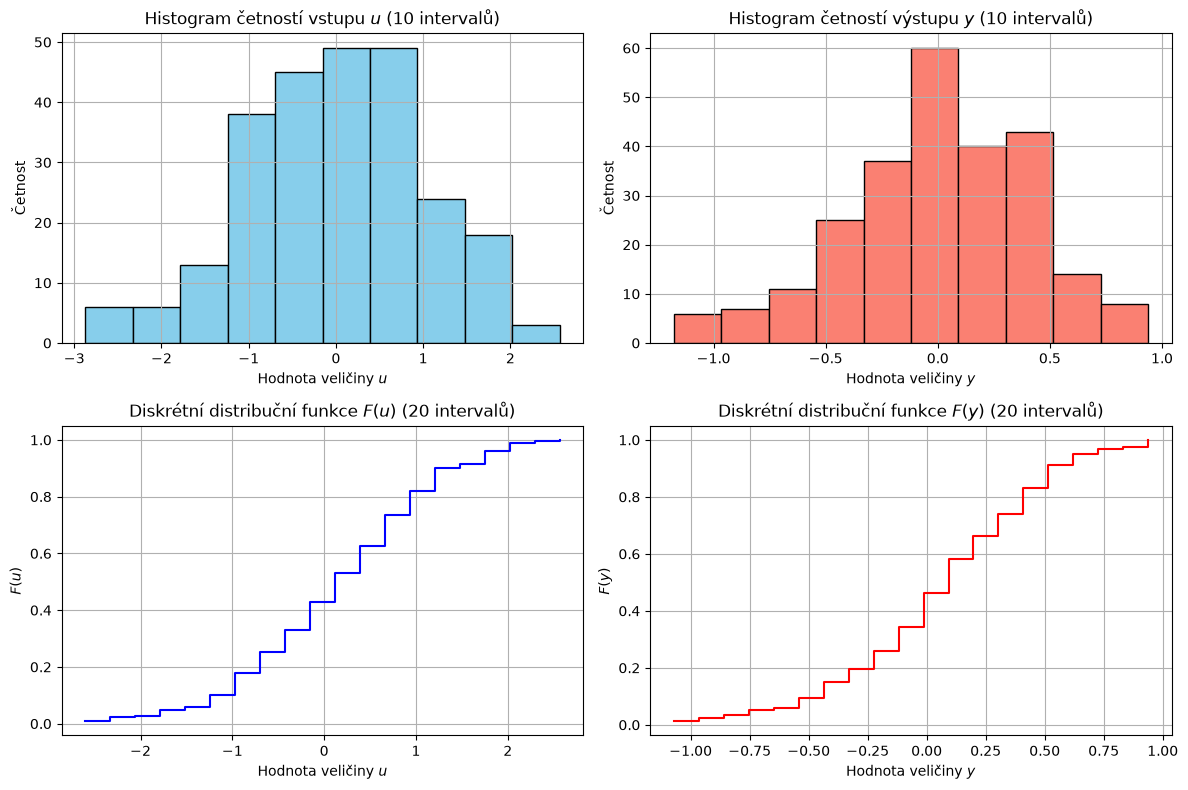

In [3]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(u, bins=10, edgecolor='black', color='skyblue')
plt.title(r'Histogram četností vstupu $u$ (10 intervalů)')
plt.xlabel(r'Hodnota veličiny $u$')
plt.ylabel('Četnost')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.hist(y, bins=10, edgecolor='black', color='salmon')
plt.title(r'Histogram četností výstupu $y$ (10 intervalů)')
plt.xlabel(r'Hodnota veličiny $y$')
plt.ylabel('Četnost')
plt.grid(True)

counts_u, bin_edges_u = np.histogram(u, bins=20)
cdf_u = np.cumsum(counts_u) / N
plt.subplot(2, 2, 3)
plt.step(bin_edges_u[1:], cdf_u, where='post', color='blue')
plt.title(r'Diskrétní distribuční funkce $F(u)$ (20 intervalů)')
plt.xlabel(r'Hodnota veličiny $u$')
plt.ylabel(r'$F(u)$')
plt.grid(True)

counts_y, bin_edges_y = np.histogram(y, bins=20)
cdf_y = np.cumsum(counts_y) / N
plt.subplot(2, 2, 4)
plt.step(bin_edges_y[1:], cdf_y, where='post', color='red')
plt.title(r'Diskrétní distribuční funkce $F(y)$ (20 intervalů)')
plt.xlabel(r'Hodnota veličiny $y$')
plt.ylabel(r'$F(y)$')
plt.grid(True)

plt.tight_layout()
plt.savefig("histogramy.png", dpi=300)
plt.show()


## Výpočet a grafické znázornění autokorelačních, vzájemných korelačních, autokovariančních a vzájemných kovariančních funkcí


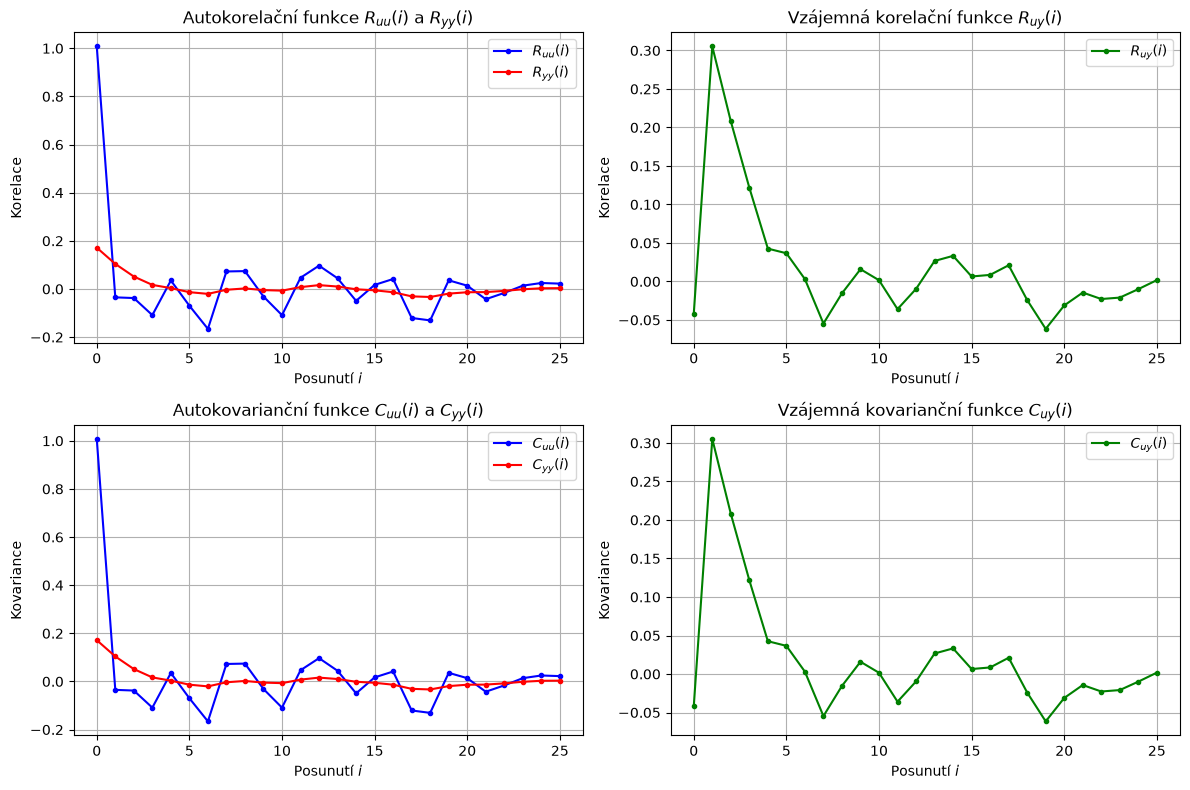

In [4]:
m = int(0.1 * N)
i_vals = np.arange(0, m + 1)

R_uu = np.zeros(m + 1)
R_yy = np.zeros(m + 1)
R_uy = np.zeros(m + 1)
C_uu = np.zeros(m + 1)
C_yy = np.zeros(m + 1)
C_uy_func = np.zeros(m + 1)

for i in range(m + 1):
    norm = N - i
    u_k = u[:norm]
    u_ki = u[i:norm + i]
    y_k = y[:norm]
    y_ki = y[i:norm + i]
    
    R_uu[i] = np.sum(u_k * u_ki) / norm
    R_yy[i] = np.sum(y_k * y_ki) / norm
    R_uy[i] = np.sum(u_k * y_ki) / norm
    
    C_uu[i] = np.sum((u_k - m_u) * (u_ki - m_u)) / norm
    C_yy[i] = np.sum((y_k - m_y) * (y_ki - m_y)) / norm
    C_uy_func[i] = np.sum((u_k - m_u) * (y_ki - m_y)) / norm

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(i_vals, R_uu, 'b.-', label=r'$R_{uu}(i)$')
plt.plot(i_vals, R_yy, 'r.-', label=r'$R_{yy}(i)$')
plt.title(r'Autokorelační funkce $R_{uu}(i)$ a $R_{yy}(i)$')
plt.xlabel(r'Posunutí $i$')
plt.ylabel('Korelace')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(i_vals, R_uy, 'g.-', label=r'$R_{uy}(i)$')
plt.title(r'Vzájemná korelační funkce $R_{uy}(i)$')
plt.xlabel(r'Posunutí $i$')
plt.ylabel('Korelace')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(i_vals, C_uu, 'b.-', label=r'$C_{uu}(i)$')
plt.plot(i_vals, C_yy, 'r.-', label=r'$C_{yy}(i)$')
plt.title(r'Autokovarianční funkce $C_{uu}(i)$ a $C_{yy}(i)$')
plt.xlabel(r'Posunutí $i$')
plt.ylabel('Kovariance')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(i_vals, C_uy_func, 'g.-', label=r'$C_{uy}(i)$')
plt.title(r'Vzájemná kovarianční funkce $C_{uy}(i)$')
plt.xlabel(r'Posunutí $i$')
plt.ylabel('Kovariance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("korelace_kovariance.png", dpi=300)
plt.show()


## Závěr

V této úloze jsem se zabýval výpočtem a analýzou základních statistických charakteristik náhodných veličin a chováním dynamické soustavy buzené náhodným signálem. 

### Postup řešení a vlastní data:
1. **Model soustavy a simulace:** Sestavil jsem si simulinkové schéma podle zadaného schématu, kde koeficienty spojitého modelu byly odvozeny z mého data narození ($a_1 = 4$, $a_2 = 12$, přenos soustavy odpovídá formátu $12s^2 + 4s + 1$). Jako buzení jsem zvolil náhodný signál typu bílý šum a periodu vzorkování jsem nastavil s ohledem na dynamiku soustavy.
2. **Zpracování dat:** Po spuštění simulace jsem hodnoty výstupu $y$ a vstupu $u$ zapsal do pole v Simulinku, data zkopíroval do Excelu a uložil jako soubory `u.csv` a `y.csv`, se kterými jsem následně pracoval v Jupyter Notebooku. Nasimuloval jsem celkem $N = 251$ vzorků.
3. **Statistická analýza:** Vypočítal jsem bodové odhady středních hodnot, rozptylů, směrodatných odchylek, kovarianční matici a koeficient korelace. Dále jsem pro vstupní i výstupní veličinu sestavil histogramy četností (10 intervalů) a diskrétní distribuční funkce (20 intervalů), a nakonec spočítal autokorelační, vzájemné korelační, autokovarianční a vzájemné kovarianční funkce.

### Shrnutí výsledků:
- **Střední hodnota:** Vstupní šum má střední hodnotu $\hat{m}_u \approx 0{,}00591$ (teoreticky 0) a výstupní signál $\hat{m}_y \approx 0{,}00789$. Protože má soustava jednotkové statické zesílení, střední hodnota se průchodem soustavou prakticky nezměnila a zůstala v okolí nuly.
- **Rozptyl:** Vstupní rozptyl $\hat{s}_u^2 \approx 1{,}00767$ se na výstupu výrazně snížil na $\hat{s}_y^2 \approx 0{,}17159$ (směrodatná odchylka klesla z $1{,}00383$ na $0{,}41424$). To je způsobeno tím, že soustava 2. řádu funguje jako dolní propust, která tlumí vysokofrekvenční složky šumu a signál vyhladí.
- **Rozložení dat a distribuce:** Histogramy potvrdily Gaussovo rozložení obou veličin, přičemž výstupní histogram je znatelně užší. Distribuční funkce mají plynulý esovitý průběh odpovídající naměřeným rozsahům.
- **Kovariance a korelace:** Vypočtená kovarianční matice se přesně shoduje s výsledkem vestavěné funkce `np.cov` (rozdíl v řádu $10^{-17}$). Koeficient vzájemné korelace $r_{uy} \approx -0{,}10041$ ukazuje na slabou okamžitou lineární závislost.
- **Korelační a kovarianční funkce:** Autokorelace vstupu $R_{uu}(i)$ má charakter bílého šumu (pík v počátku, jinak nulová korelace), zatímco výstupní autokorelace $R_{yy}(i)$ pozvolna klesá vlivem setrvačnosti a paměti systému. Vzájemná korelace $R_{uy}(i)$ věrně zachycuje dynamickou odezvu soustavy na vstupní buzení.
